## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
augmentation = False
augmentation_weights = [0.9, 0.1]
proportion_of_augmented = 0.25

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) przedziały ufności

## Loading the data

In [3]:
data_path = '../data/DANE.xlsx'
figures_path = '../results/visualisations/'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [8]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [9]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's remove rows with missing values.

In [10]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [11]:
inDKs_df.dropna(inplace=True)

2. Let's keep only columns that we need.

In [12]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [13]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

In [14]:
inDKs_df = inDKs_df[inks_colnames + inds_colnames + ['Sample_id']]

### Train test split, datasets, dataloaders

In [15]:
if keep_sample_together:
    indices = list(range(inDKs_df['Sample_id'].max()))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [16]:
# if augmentation:
#     X_train = torch.cat([X_train, X_aug])
#     y_train = torch.cat([y_train, y_aug])

### Data augmentation

In [17]:
if real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [18]:
if real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))
    
    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']
    
    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [19]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']
if augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[inds_colnames].values)
y_train = np.array(X_y_train[inks_colnames].values)
X_val = np.array(X_y_val[inds_colnames].values)
y_val = np.array(X_y_val[inks_colnames].values)
X_test = np.array(X_y_test[inds_colnames].values)
y_test = np.array(X_y_test[inks_colnames].values)
if augmentation:
    X_augmented = np.array(X_y_augmented[inds_colnames].values)
    y_augmented = np.array(X_y_augmented[inks_colnames].values)

### Normalization

No normalization is needed in this case, as we use adjusted log transformation instead.

In [20]:
# if augmentation:
#     X_all = np.concatenate([X_train, X_augmented])
#     y_all = np.concatenate([y_train, y_augmented])
    
#     X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
#     y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)
        
#     X_train = X_all[:X_train.shape[0],:]
#     X_augmented = X_all[X_train.shape[0]:,:]
#     y_train = y_all[:y_train.shape[0],:]
#     y_augmented = y_all[y_train.shape[0]:,:]
# else:
#     X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
#     y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)
    
# X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
# y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

# X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
# y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

### Adjusted log transform

In [21]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [22]:
X_train = adjusted_log_transform(X_train)
y_train = adjusted_log_transform(y_train)
X_val = adjusted_log_transform(X_val)
y_val = adjusted_log_transform(y_val)
X_test = adjusted_log_transform(X_test)
y_test = adjusted_log_transform(y_test)

/tmp/ipykernel_7548/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


### Converting to tensors

In [23]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [24]:
if augmentation:
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
else:
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [25]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [26]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [27]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [28]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [29]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [30]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [31]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [32]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [33]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [34]:
EPOCHS = 15000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.299491612116496 test 3.2713731608775833
EPOCH 2:
LOSS train 3.2952920118967692 test 3.2634140709665744
EPOCH 3:
LOSS train 3.2883119106292726 test 3.25513888367955
EPOCH 4:
LOSS train 3.2784681797027586 test 3.246288367926951
EPOCH 5:
LOSS train 3.2647667090098063 test 3.2368096115673057
EPOCH 6:
LOSS train 3.258111921946208 test 3.226507605232807
EPOCH 7:
LOSS train 3.249644915262858 test 3.215233463925111
EPOCH 8:
LOSS train 3.2320672194163005 test 3.202945211659307
EPOCH 9:
LOSS train 3.2216718991597495 test 3.189476633911054
EPOCH 10:
LOSS train 3.209101994832357 test 3.174606880539446
EPOCH 11:
LOSS train 3.194146712621053 test 3.1584088918338407
EPOCH 12:
LOSS train 3.1694807052612304 test 3.1406943393296585
EPOCH 13:
LOSS train 3.1558867931365966 test 3.121016352319816
EPOCH 14:
LOSS train 3.137459961573283 test 3.0988418584531385
EPOCH 15:
LOSS train 3.1116536617279054 test 3.074430695972087
EPOCH 16:
LOSS train 3.0901456514994305 test 3.0482918374533488
E

LOSS train 1.1418013334274293 test 1.1291273581808892
EPOCH 132:
LOSS train 1.138409423828125 test 1.1281783587567307
EPOCH 133:
LOSS train 1.1416950941085815 test 1.1272344305401756
EPOCH 134:
LOSS train 1.1370950619379678 test 1.1259848232965293
EPOCH 135:
LOSS train 1.1348599831263224 test 1.124390716570011
EPOCH 136:
LOSS train 1.1268914182980856 test 1.12245033591924
EPOCH 137:
LOSS train 1.1330324252446493 test 1.120404468004748
EPOCH 138:
LOSS train 1.1297535181045533 test 1.1184348331351706
EPOCH 139:
LOSS train 1.126256275177002 test 1.1168330273519638
EPOCH 140:
LOSS train 1.127902865409851 test 1.1152850508566476
EPOCH 141:
LOSS train 1.1241442680358886 test 1.1137132425609335
EPOCH 142:
LOSS train 1.123242457707723 test 1.1122002315940818
EPOCH 143:
LOSS train 1.1192822376887004 test 1.1107195069701035
EPOCH 144:
LOSS train 1.1197562376658121 test 1.1092808901893427
EPOCH 145:
LOSS train 1.1209017833073933 test 1.1077120734174306
EPOCH 146:
LOSS train 1.1171372016270955 tes

LOSS train 0.9804954250653585 test 0.967353697087207
EPOCH 260:
LOSS train 0.9773379961649576 test 0.966920390755987
EPOCH 261:
LOSS train 0.9771596193313599 test 0.9665529786861708
EPOCH 262:
LOSS train 0.9746408343315125 test 0.9662328637966705
EPOCH 263:
LOSS train 0.9711022814114888 test 0.965829089623307
EPOCH 264:
LOSS train 0.9724350730578105 test 0.9654691751822675
EPOCH 265:
LOSS train 0.9754306077957153 test 0.965014893631017
EPOCH 266:
LOSS train 0.9723686615626017 test 0.9647672964919428
EPOCH 267:
LOSS train 0.9733084519704183 test 0.9643198246479529
EPOCH 268:
LOSS train 0.9751811106999715 test 0.9642712632753341
EPOCH 269:
LOSS train 0.972800628344218 test 0.9637888084719146
EPOCH 270:
LOSS train 0.9722356677055359 test 0.9635397161571135
EPOCH 271:
LOSS train 0.9699148694674175 test 0.9631506411000068
EPOCH 272:
LOSS train 0.9727794170379639 test 0.9629305569960217
EPOCH 273:
LOSS train 0.9676502625147502 test 0.9627232113795251
EPOCH 274:
LOSS train 0.9707536617914836 

LOSS train 0.9454627792040508 test 0.9426314757354017
EPOCH 388:
LOSS train 0.9470498959223429 test 0.9423211465587774
EPOCH 389:
LOSS train 0.943866781393687 test 0.942139981542068
EPOCH 390:
LOSS train 0.9446409265200297 test 0.9422657510755472
EPOCH 391:
LOSS train 0.9447369615236918 test 0.9418768585653778
EPOCH 392:
LOSS train 0.9474749763806661 test 0.9417801166481606
EPOCH 393:
LOSS train 0.9436178962389629 test 0.941654015432727
EPOCH 394:
LOSS train 0.9446847637494405 test 0.9415864864861743
EPOCH 395:
LOSS train 0.9426045060157776 test 0.9414972067496298
EPOCH 396:
LOSS train 0.9445743560791016 test 0.9412896815170659
EPOCH 397:
LOSS train 0.9458122928937276 test 0.9412116778563269
EPOCH 398:
LOSS train 0.9450745224952698 test 0.94102971737059
EPOCH 399:
LOSS train 0.9428748329480489 test 0.9409568932670984
EPOCH 400:
LOSS train 0.9419050812721252 test 0.9408593586883189
EPOCH 401:
LOSS train 0.9398411870002746 test 0.9407487621156819
EPOCH 402:
LOSS train 0.942998719215393 t

LOSS train 0.9271913568178812 test 0.9266371743340917
EPOCH 516:
LOSS train 0.9227527022361756 test 0.9265356476632705
EPOCH 517:
LOSS train 0.9265579581260681 test 0.9264129278082285
EPOCH 518:
LOSS train 0.9271431763966879 test 0.9262077618953357
EPOCH 519:
LOSS train 0.9256696025530498 test 0.9259929445034228
EPOCH 520:
LOSS train 0.9243113120396932 test 0.9258588025535363
EPOCH 521:
LOSS train 0.9232052604357401 test 0.9258299097881554
EPOCH 522:
LOSS train 0.9233963410059611 test 0.9256982893430421
EPOCH 523:
LOSS train 0.9246182799339294 test 0.9255529982703072
EPOCH 524:
LOSS train 0.9230971574783325 test 0.9254562519105078
EPOCH 525:
LOSS train 0.9245566407839457 test 0.9252505378940338
EPOCH 526:
LOSS train 0.9237858295440674 test 0.9251109730629694
EPOCH 527:
LOSS train 0.9194004813830058 test 0.9250181599926998
EPOCH 528:
LOSS train 0.9221260945002238 test 0.9248736827763465
EPOCH 529:
LOSS train 0.9249788602193196 test 0.9247879804908365
EPOCH 530:
LOSS train 0.922643089294

...

LOSS train 0.6432622989018758 test 0.6738636952132665
EPOCH 14435:
LOSS train 0.6469169616699219 test 0.6738222930310429
EPOCH 14436:
LOSS train 0.6437545975049337 test 0.6742417913539562
EPOCH 14437:
LOSS train 0.6431197206179301 test 0.6738216055105932
EPOCH 14438:
LOSS train 0.6455637017885844 test 0.673833042506599
EPOCH 14439:
LOSS train 0.6450096607208252 test 0.6742107570788382
EPOCH 14440:
LOSS train 0.6468842029571533 test 0.6738981990216929
EPOCH 14441:
LOSS train 0.6494901895523071 test 0.6740171818938068
EPOCH 14442:
LOSS train 0.6460579792658488 test 0.6739969657691616
EPOCH 14443:
LOSS train 0.643958059946696 test 0.673918607750788
EPOCH 14444:
LOSS train 0.6446533958117168 test 0.6739473121074909
EPOCH 14445:
LOSS train 0.6424839297930399 test 0.67392553549499
EPOCH 14446:
LOSS train 0.645166810353597 test 0.6742821821699971
EPOCH 14447:
LOSS train 0.6447274883588155 test 0.6736486340038031
EPOCH 14448:
LOSS train 0.6409178654352824 test 0.6741239368360236
EPOCH 14449:
L

LOSS train 0.6440266251564026 test 0.6733846604885768
EPOCH 14559:
LOSS train 0.642648983001709 test 0.6737277579973944
EPOCH 14560:
LOSS train 0.6467644413312276 test 0.6737117707174017
EPOCH 14561:
LOSS train 0.6424872001012166 test 0.673596731871058
EPOCH 14562:
LOSS train 0.6433812379837036 test 0.6735759829450592
EPOCH 14563:
LOSS train 0.6465499242146809 test 0.6736681245375371
EPOCH 14564:
LOSS train 0.6441899339358012 test 0.6736954025785375
EPOCH 14565:
LOSS train 0.6457234779993694 test 0.6737577016185776
EPOCH 14566:
LOSS train 0.6427305897076925 test 0.6738127577070371
EPOCH 14567:
LOSS train 0.6456653316815694 test 0.6736767084702201
EPOCH 14568:
LOSS train 0.6435636560122172 test 0.673676261867302
EPOCH 14569:
LOSS train 0.6448934237162273 test 0.6735657731506889
EPOCH 14570:
LOSS train 0.6435065110524495 test 0.6736354319452006
EPOCH 14571:
LOSS train 0.6431045373280843 test 0.6736947308539357
EPOCH 14572:
LOSS train 0.6441896200180054 test 0.6737542691993417
EPOCH 14573

LOSS train 0.6437215288480123 test 0.6734307525259121
EPOCH 14683:
LOSS train 0.6459080497423808 test 0.6732883507975881
EPOCH 14684:
LOSS train 0.6436010917027791 test 0.6734297929898553
EPOCH 14685:
LOSS train 0.647111157576243 test 0.6733148632027348
EPOCH 14686:
LOSS train 0.6452417294184367 test 0.6732566018220554
EPOCH 14687:
LOSS train 0.6455390969912211 test 0.6733348844090851
EPOCH 14688:
LOSS train 0.6437518080075582 test 0.6734985159112307
EPOCH 14689:
LOSS train 0.6463509599367777 test 0.6733894587858863
EPOCH 14690:
LOSS train 0.6445911566416422 test 0.6733885084435066
EPOCH 14691:
LOSS train 0.6447390198707581 test 0.6735203285580096
EPOCH 14692:
LOSS train 0.6416580994923909 test 0.6733272070408362
EPOCH 14693:
LOSS train 0.6451963146527608 test 0.6734062122262042
EPOCH 14694:
LOSS train 0.6437999129295349 test 0.6734613846856368
EPOCH 14695:
LOSS train 0.6456897934277852 test 0.6734693179342811
EPOCH 14696:
LOSS train 0.6409872889518737 test 0.6733207101962582
EPOCH 146

LOSS train 0.6439299424489339 test 0.6732970714939307
EPOCH 14807:
LOSS train 0.6433629314104716 test 0.672936014877343
EPOCH 14808:
LOSS train 0.6464502533276876 test 0.673109280458395
EPOCH 14809:
LOSS train 0.6442795634269715 test 0.6731595975148258
EPOCH 14810:
LOSS train 0.6456019838651021 test 0.6729928853904238
EPOCH 14811:
LOSS train 0.6442828098932902 test 0.6732923818856292
EPOCH 14812:
LOSS train 0.643506666024526 test 0.673176617294118
EPOCH 14813:
LOSS train 0.6394246459007263 test 0.6731480942503019
EPOCH 14814:
LOSS train 0.6445499817530315 test 0.6729462036311503
EPOCH 14815:
LOSS train 0.6438342054684957 test 0.6730824575969645
EPOCH 14816:
LOSS train 0.6435606122016907 test 0.6728846786185081
EPOCH 14817:
LOSS train 0.6424341678619385 test 0.6731431163369251
EPOCH 14818:
LOSS train 0.6428355813026428 test 0.6731323405143884
EPOCH 14819:
LOSS train 0.6429588913917541 test 0.6732209514880526
EPOCH 14820:
LOSS train 0.6413676659266154 test 0.6727952958078858
EPOCH 14821:

LOSS train 0.6425995071729024 test 0.6727944211745114
EPOCH 14931:
LOSS train 0.6435081839561463 test 0.6729579561430475
EPOCH 14932:
LOSS train 0.6451660593350729 test 0.6727151052860493
EPOCH 14933:
LOSS train 0.6437685052553813 test 0.6728168184836212
EPOCH 14934:
LOSS train 0.6452391306559245 test 0.6728121984757746
EPOCH 14935:
LOSS train 0.6435039599736532 test 0.6728018768764183
EPOCH 14936:
LOSS train 0.6430884043375651 test 0.6729298975958834
EPOCH 14937:
LOSS train 0.6423871080080669 test 0.6727511706312744
EPOCH 14938:
LOSS train 0.6420342763264973 test 0.6732040692745529
EPOCH 14939:
LOSS train 0.6427154024442037 test 0.6727506752216544
EPOCH 14940:
LOSS train 0.6423864444096883 test 0.6729534744105724
EPOCH 14941:
LOSS train 0.6428839564323425 test 0.6728055291109204
EPOCH 14942:
LOSS train 0.6436652501424154 test 0.6730044465627729
EPOCH 14943:
LOSS train 0.6459331194559733 test 0.6725818699931506
EPOCH 14944:
LOSS train 0.6453981200853983 test 0.6729660856674423
EPOCH 14

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

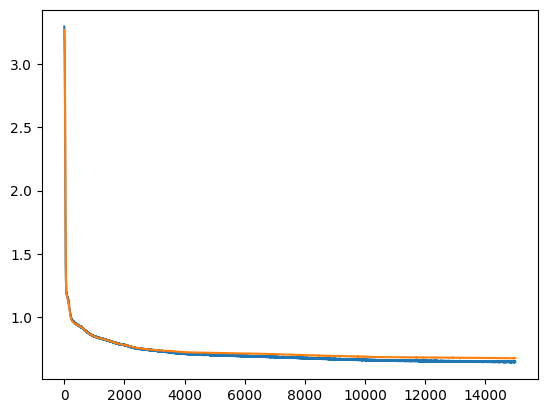

In [35]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

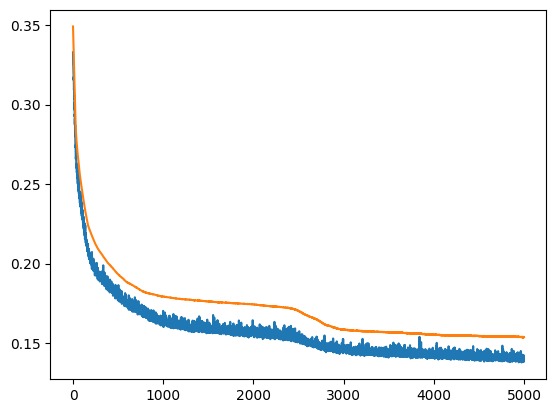

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

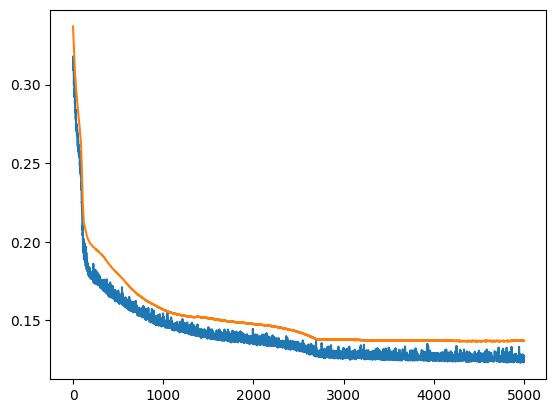

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

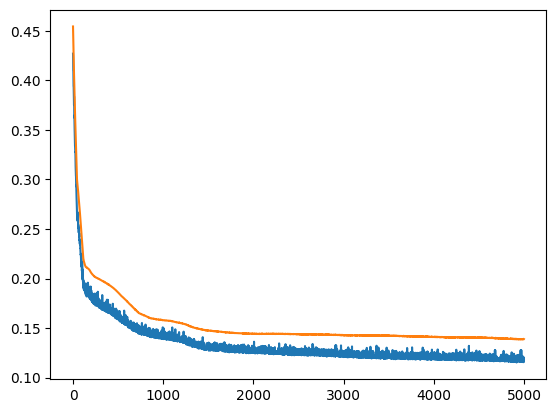

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

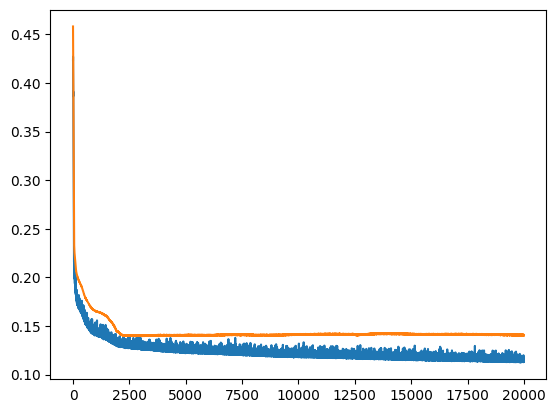

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

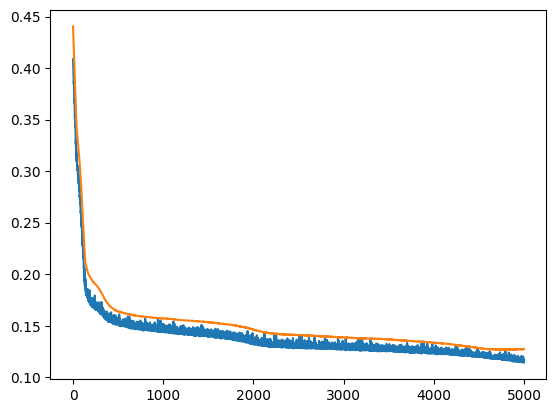

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#8 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/3, 1/3, 1/18, 1/18, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

In [ ]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [36]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [37]:
lab

tensor([[  2.3608,  -4.6928,  -5.3369,  ...,  -2.8322,  -3.1945,  -0.5643],
        [ -1.6136,  -5.6535, -10.1311,  ...,  -3.9706,  -6.0728,  -3.0429],
        [  1.4758,  -2.8417,  -5.6984,  ...,  -4.0463,  -4.9353,  -0.4143],
        ...,
        [  2.3260,  -4.5822,  -8.4662,  ...,  -4.1836,  -5.4901,   0.5638],
        [  1.5246,  -5.3020,  -9.2955,  ...,   0.2817,  -5.3605,  -3.0436],
        [  1.4058,  -3.7851,  -6.3030,  ...,  -2.6775,  -6.1157,  -0.2557]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [38]:
out

tensor([[ 1.0668, -4.5978, -9.3674,  ..., -3.7288, -3.5484, -1.1705],
        [-0.4877, -4.1613, -8.8806,  ..., -4.3285, -4.8118, -2.6421],
        [ 1.7030, -3.5746, -6.3665,  ..., -3.1953, -5.5488,  0.5413],
        ...,
        [ 2.6270, -5.0182, -8.0366,  ..., -3.9027, -4.6129,  0.4070],
        [ 0.6217, -4.0856, -8.6604,  ..., -1.2653, -5.4688, -2.5820],
        [ 0.2554, -4.1923, -8.1762,  ..., -3.1101, -6.6969, -0.2778]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [39]:
res

tensor([[1.2940, 0.0950, 4.0305,  ..., 0.8966, 0.3539, 0.6062],
        [1.1258, 1.4922, 1.2505,  ..., 0.3579, 1.2610, 0.4008],
        [0.2272, 0.7328, 0.6681,  ..., 0.8511, 0.6136, 0.9556],
        ...,
        [0.3009, 0.4361, 0.4297,  ..., 0.2809, 0.8772, 0.1568],
        [0.9029, 1.2165, 0.6351,  ..., 1.5470, 0.1083, 0.4615],
        [1.1504, 0.4072, 1.8733,  ..., 0.4325, 0.5812, 0.0222]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [40]:
torch.mean(res, axis=0) 

tensor([0.6059, 0.7455, 0.9681, 0.4643, 0.6565, 0.6488, 0.7229, 0.4996],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [ ]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [40]:
torch.mean(res)

tensor(0.1623, device='cuda:0', grad_fn=<MeanBackward0>)

In [42]:
torch.mean(res)

tensor(0.6639, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [43]:
dim_nr = 5
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [44]:
#torch.max(out, axis=0)

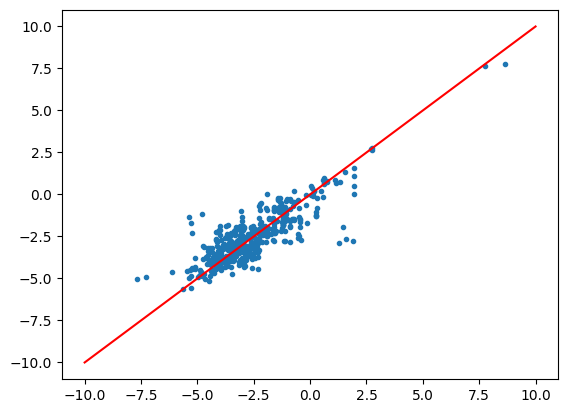

In [47]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )
# plt.xlim(-0.1, 0.1)
# plt.ylim(-0.1, 0.1)

In [48]:
torch.mean(res, 0)

tensor([0.6059, 0.7455, 0.9681, 0.4643, 0.6565, 0.6488, 0.7229, 0.4996],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [49]:
mean_loss

0.663945675112199

## Quality of prediction: closest points

#### Creating df with means of classes

In [98]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [99]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
# for name in elements_names:
#     mean_sd_df[name + '_sd'] = train_val_data_normalized_df.groupby('Sample_id')[name].transform(np.std)
#     mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_7548/4209521825.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_7548/4209521825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7548/4209521825.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance wor it to work: if in test set classes in y_test are close to means of classes in train_val set

In [ ]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [ ]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [100]:
closest = []
for i in range(y_test_df.shape[0]):
    closest.append((abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [101]:
len(closest)

483

In [102]:
y_test_df['Closest'] = closest

In [103]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0]

438

In [104]:
438/483

0.906832298136646

Looks resonably: for around 90% of cases in y, the class from X with the nearest mean is the actual y's class.

#### Now let's check if it works for the neural network's output.

In [ ]:
model.eval()
outputs = model(X_test)

In [ ]:
outputs.shape

In [107]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [109]:
closest = []
for i in range(outputs_df.shape[0]):
    closest.append((abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [110]:
len(closest)

483

In [111]:
outputs_df['Closest'] = closest

In [112]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

151

Around 1/3, poor.

## Quality of prediction: confidence intervals

In [75]:
model.eval()
outputs = model(X_test)

In [76]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [77]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu()), 
                        pd.DataFrame(y_test.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order, test_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [80]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
min_df = min_max_df.iloc[:,1+len(elements_names):]

/tmp/ipykernel_7548/4042430873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_7548/4042430873.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7548/4042430873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [81]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)

/tmp/ipykernel_7548/3639753013.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_7548/3639753013.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7548/3639753013.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [82]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > np.array(min_df.iloc[sample_id,:])
    
    less_than_max = test_example.cpu().detach().numpy() < np.array(max_df.iloc[sample_id,:])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [83]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > np.array(lower_bound_df.iloc[sample_id,:])
    
    less = test_example.cpu().detach().numpy() < np.array(upper_bound_df.iloc[sample_id,:])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [84]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

In [85]:
np.array(sd_res_list).mean()

0.42054865424430643

In [86]:
np.array(sd_res_list).mean(0)

array([0.59834369, 0.44306418, 0.436853  , 0.33954451, 0.29813665,
       0.38095238, 0.3747412 , 0.49275362])

In [87]:
np.array(min_max_res_list).mean(0)

array([0.50517598, 0.4057971 , 0.38302277, 0.28364389, 0.26293996,
       0.33333333, 0.34782609, 0.41614907])

In [88]:
np.array(min_max_res_list).mean()

0.3672360248447205

In [89]:
np.array(min_max_res_list).mean(0)

array([0.50517598, 0.4057971 , 0.38302277, 0.28364389, 0.26293996,
       0.33333333, 0.34782609, 0.41614907])

In [90]:
%matplotlib notebook

In [91]:
outputs.shape

torch.Size([483, 8])

In [92]:
%matplotlib notebook

<IPython.core.display.Javascript object>


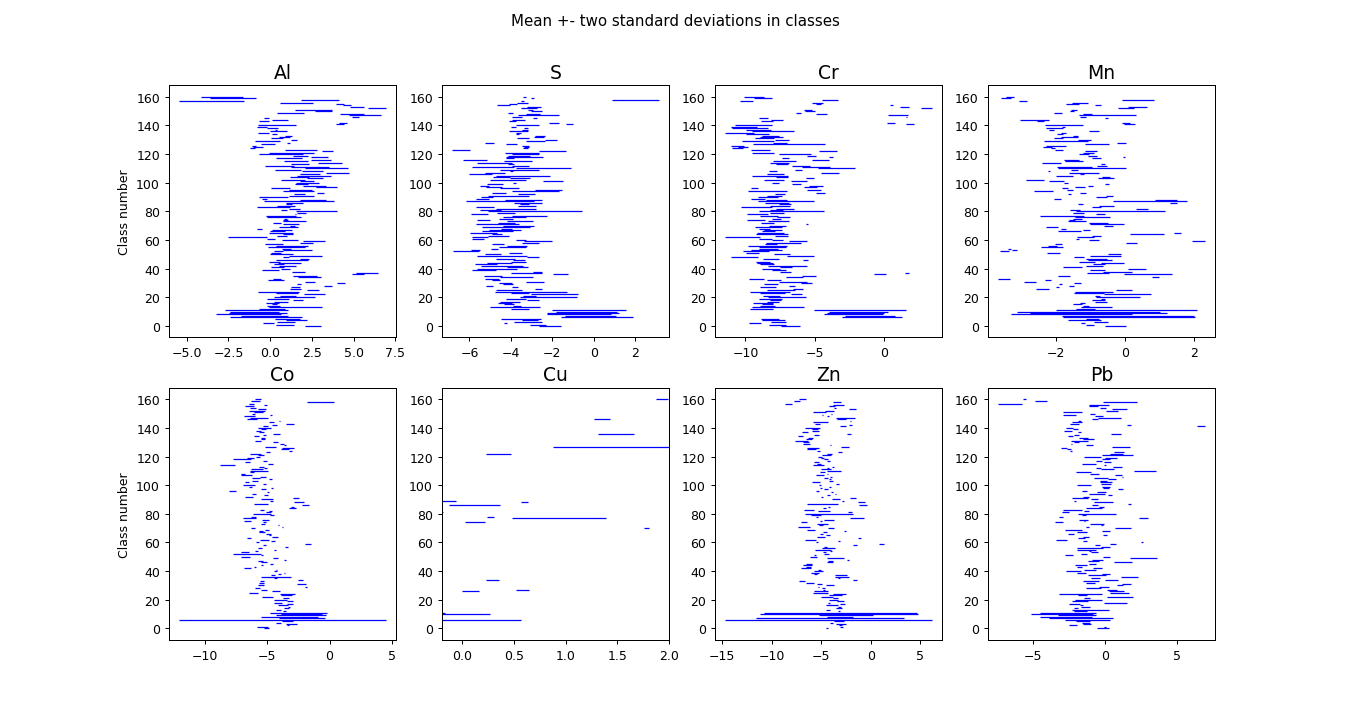

In [93]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

<IPython.core.display.Javascript object>


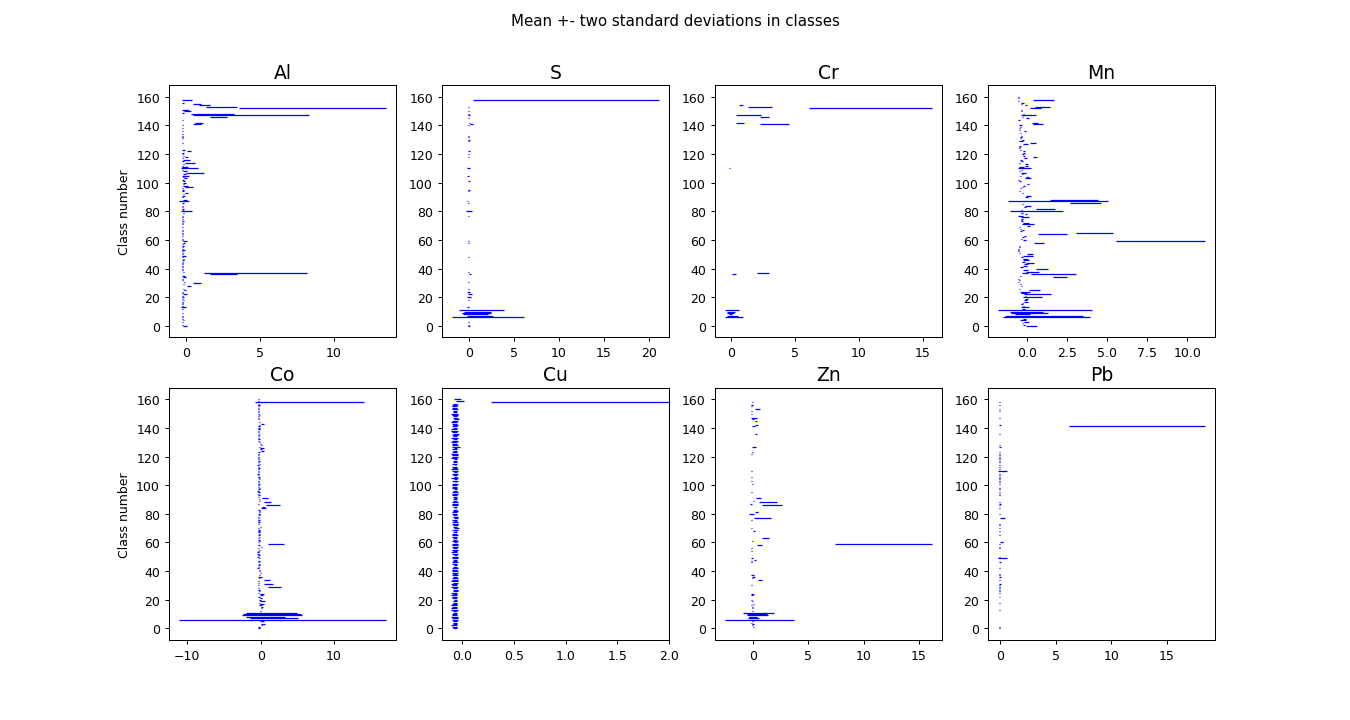

In [111]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

<IPython.core.display.Javascript object>


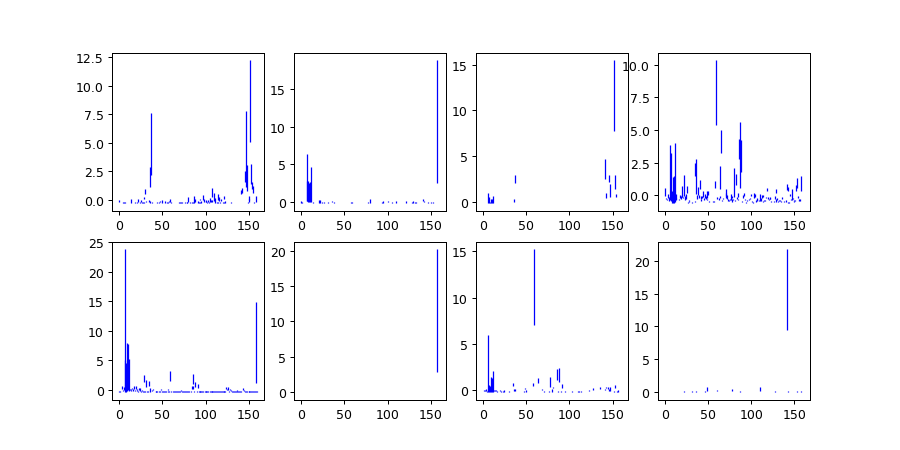

In [104]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

<IPython.core.display.Javascript object>


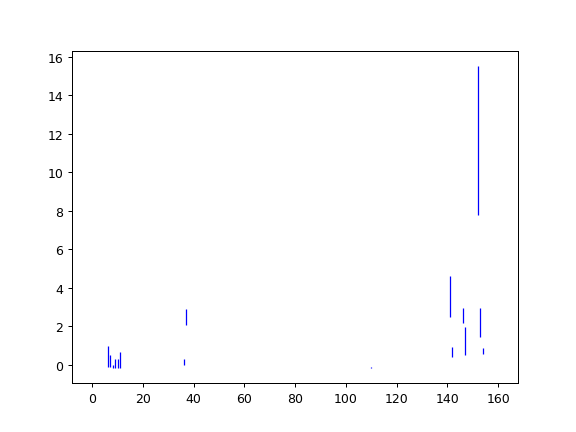

In [108]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

In [ ]:
inside_min_max_interval = torch.cat([res.unsqueeze(0) for res in res_list])

In [ ]:
(inside_min_max_interval*1.0).mean(axis=0)

In [48]:
(inside_min_max_interval*1.0).mean(axis=0) #best weights: 1/2, 1/4, 1/8, 1/40, ...

tensor([0.2854, 0.3729, 0.0542, 0.0729, 0.0625, 0.0500, 0.0125, 0.2188],
       device='cuda:0')

In [44]:
from_sample.mean(axis=0)

tensor([ 5.0448, -0.1901,  5.1446, -0.1243, -0.5578,  0.0341, -0.1956,  0.1323],
       device='cuda:0')

In [46]:
from_sample.std(axis=0)

tensor([0.7062, 0.0081, 0.2986, 0.0153, 0.0049, 0.0180, 0.0018, 0.0793],
       device='cuda:0')

(array([2., 1., 0., 4., 3., 2., 0., 0., 2., 1.]),
 array([0.0093034 , 0.03666412, 0.06402484, 0.09138557, 0.11874629,
        0.146107  , 0.17346773, 0.20082845, 0.22818917, 0.25554991,
        0.28291062]),
 <BarContainer object of 10 artists>)

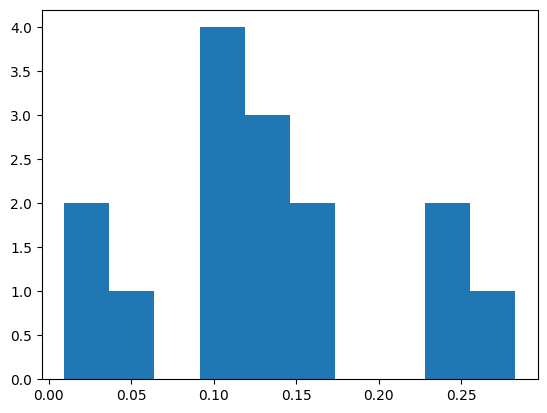

In [67]:
plt.hist(np.array(from_sample[:,7].cpu()))

## Interpretability

...